# **Google Play Store Apps**

## **Problem Statement**

Analyze Google Play Store data to understand factors affecting app success (ratings & installs).
Clean and preprocess the dataset, then explore relationships between features like reviews, price, and size.
Generate insights to help improve app performance and user engagement.



## **Tools** & Technologies
Python

Pandas

NumPy

Matplotlib

Seaborn

SciPy (stats)

Scikit-learn

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings("ignore")

%matplotlib inline


## Load **Dataset**

The dataset contains information about Google Play Store applications, including details such as app name, category, rating, reviews, size, installs, price, and content rating. It is used to analyze app performance, user engagement, and trends across different categories on the Play Store platform.

In [ ]:
apps_df = pd.read_csv("/content/googleplaystore.csv")
reviews_df = pd.read_csv("/content/googleplaystore_user_reviews.csv")


## **Dataset Overview**

In this step, we examine the structure of the Google Play Store dataset, including data types, number of columns, and presence of missing or inconsistent values. This helps in understanding the dataset and identifying necessary preprocessing steps before analysis.

In [ ]:
apps_df.head()
apps_df.shape
apps_df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10841 entries, 0 to 10840
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   App             10841 non-null  object 
 1   Category        10841 non-null  object 
 2   Rating          9367 non-null   float64
 3   Reviews         10841 non-null  object 
 4   Size            10841 non-null  object 
 5   Installs        10841 non-null  object 
 6   Type            10840 non-null  object 
 7   Price           10841 non-null  object 
 8   Content Rating  10840 non-null  object 
 9   Genres          10841 non-null  object 
 10  Last Updated    10841 non-null  object 
 11  Current Ver     10833 non-null  object 
 12  Android Ver     10838 non-null  object 
dtypes: float64(1), object(12)
memory usage: 1.1+ MB


In [ ]:
apps_df.drop(10472, inplace=True)


In [ ]:
apps_df["Reviews"] = apps_df["Reviews"].astype(int)


In [ ]:
apps_df["Installs"] = (
    apps_df["Installs"]
    .str.replace(",", "")
    .str.replace("+", "")
    .astype(int)
)


In [ ]:
apps_df["Price"] = apps_df["Price"].str.replace("$", "").astype(float)


In [ ]:
def size_to_bytes(size):
    if isinstance(size, str):
        if size.endswith("M"):
            return float(size.replace("M", "")) * 1024 * 1024
        elif size.endswith("k"):
            return float(size.replace("k", "")) * 1024
        else:
            return np.nan
    return np.nan

apps_df["Size_in_bytes"] = apps_df["Size"].apply(size_to_bytes)
apps_df["Size_MB"] = apps_df["Size_in_bytes"] / (1024 * 1024)


In [ ]:
apps_df.isnull().sum().sort_values(ascending=False)


,0
Size_in_bytes,1695
Size_MB,1695
Rating,1474
Current Ver,8
Android Ver,2
Type,1
App,0
Installs,0
Size,0
Reviews,0


In [ ]:
bins = [-1, 0, 10, 1000, 10000, 100000, 1000000, 10000000, 10000000000]
labels = [
    "no", "Very low", "Low", "Moderate",
    "More than moderate", "High", "Very High", "Top Notch"
]

apps_df["Installs_category"] = pd.cut(
    apps_df["Installs"], bins=bins, labels=labels
)


In [ ]:
numeric_cols = [
    "Rating", "Reviews", "Size_in_bytes",
    "Installs", "Price", "Size_MB"
]

corr = apps_df[numeric_cols].corr()


In [ ]:
clean_df = apps_df.dropna(subset=["Reviews", "Installs"])
pearson_r, _ = stats.pearsonr(clean_df["Reviews"], clean_df["Installs"])
pearson_r


np.float64(0.6431220683230668)

In [ ]:
category_means = apps_df.groupby("Installs_category")["Rating"].mean()

for cat, mean_val in category_means.items():
    apps_df.loc[
        (apps_df["Installs_category"] == cat) &
        (apps_df["Rating"].isnull()),
        "Rating"
    ] = mean_val


In [ ]:
apps_df.dropna(
    subset=["Category", "Type", "Genres", "Android Ver", "Current Ver"],
    inplace=True
)

apps_df.drop_duplicates(inplace=True)
apps_df.shape


(10346, 16)

## **Data Cleaning & Preprocessing**

- Removed an invalid row (index 10472) to eliminate incorrect data.  
- Converted **"Reviews"** column to integer for numerical analysis.  
- Cleaned **"Installs"** by removing commas and "+" signs, then converted to integer.  
- Cleaned **"Price"** by removing "$" symbol and converting to float.  



## **Feature Engineering**

- Converted **"Size"** column into numerical format (bytes and MB) using a custom function.  
- Created a new column **"Size_MB"** for easier interpretation.  
- Categorized apps into groups like *Very Low, Low, Moderate, High,* etc., based on installs.  



## **Handling Missing Values**

- Identified missing values using `.isnull()`.  
- Filled missing **"Rating"** values using the average rating of their respective install category.  
- Dropped rows with critical missing values (**Category, Type, Genres, Android Ver, Current Ver**).  
- Removed duplicate records to ensure data quality.  



## **Statistical Analysis**

- Calculated correlation between numerical features.  
- Found **Pearson correlation ≈ 0.64** between **Reviews and Installs**, indicating a strong positive relationship.  


## **Final Dataset**

- Final cleaned dataset contains **10,346 rows and 16 columns**, ready for analysis and modeling.  

## **Exploratory Data Analysis (EDA)**

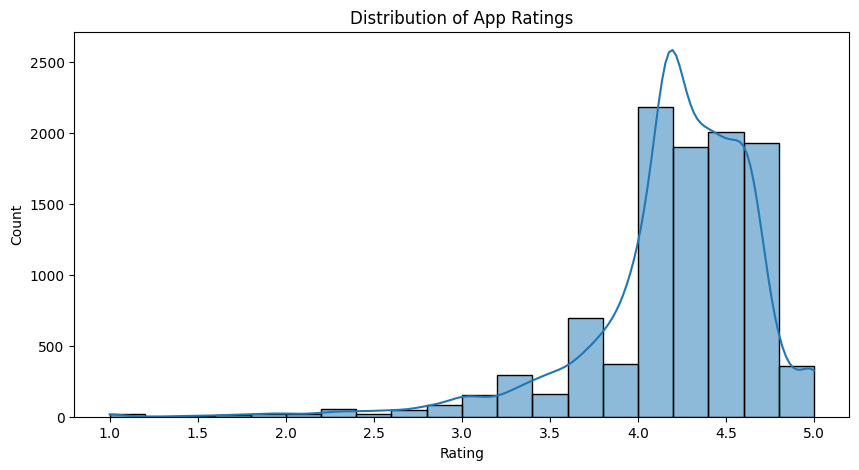

In [ ]:
plt.figure(figsize=(10,5))
sns.histplot(apps_df["Rating"], bins=20, kde=True)
plt.title("Distribution of App Ratings")
plt.show()


## **Distribution of App Ratings**

### **What this chart shows**

This chart displays the distribution of app ratings available on the Google Play Store.


### **Key observations**

- Most apps have ratings between **4.0 and 4.5**, indicating generally positive user feedback  
- Very few apps have extremely low ratings (below 2.0)  
- The distribution is slightly skewed towards higher ratings  


### **Business insight**

The majority of apps receiving high ratings suggests that users tend to rate apps positively when satisfied. High ratings play a crucial role in influencing downloads and user trust.



### **Actionable recommendation**

- Focus on improving user experience to maintain ratings above **4.0**  
- Monitor low-rated apps to identify common issues and improve performance  
- Encourage satisfied users to leave reviews and ratings  



### **Key takeaway**

Most apps on the Play Store are well-rated, and maintaining high ratings is essential for increasing installs and user trust.

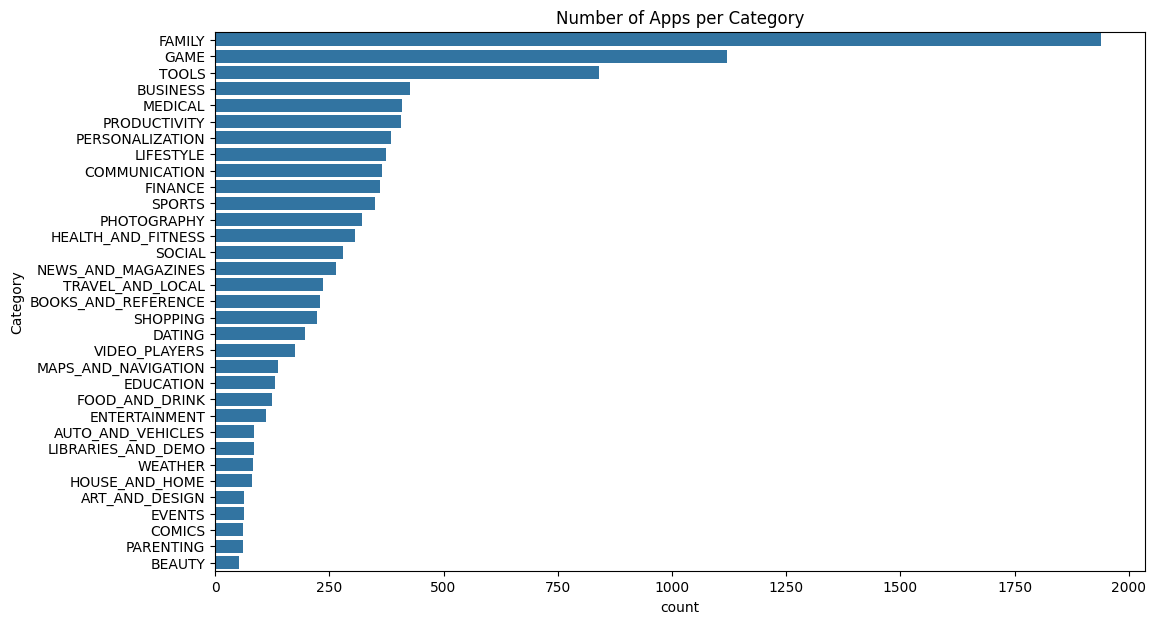

In [ ]:
plt.figure(figsize=(12,7))
sns.countplot(
    y="Category",
    data=apps_df,
    order=apps_df["Category"].value_counts().index
)
plt.title("Number of Apps per Category")
plt.show()


## **Number of Apps per Category**

### **What this chart shows**

This chart displays the number of applications available in each category on the Google Play Store.

### **Key observations**

- Certain categories like **Family, Game, and Tools** have the highest number of apps  
- Many categories have significantly fewer apps, showing uneven distribution  
- The Play Store is heavily concentrated around a few popular categories  

### **Business insight**

Developers tend to focus on popular categories due to higher demand and user base. However, this also increases competition in those categories.

### **Actionable recommendation**

- Explore less crowded categories to reduce competition and increase visibility  
- Focus on differentiation and innovation in highly saturated categories  
- Analyze user demand before choosing a category for app development  

### **Key takeaway**

A few categories dominate the Play Store, making competition high, while niche categories offer opportunities for growth.


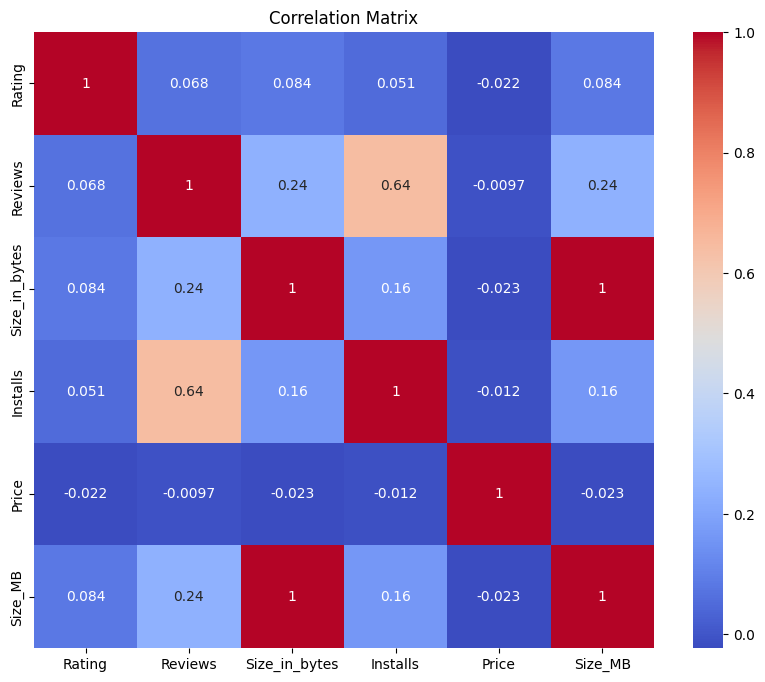

In [ ]:
plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()


## **Correlation Matrix**

### **What this chart shows**

This heatmap displays the correlation between numerical features such as Rating, Reviews, Installs, Price, and App Size.

### **Key observations**

- **Reviews and Installs** show a strong positive correlation  
- **Rating** has a weak correlation with most other features  
- **Price** has little to no correlation with installs or ratings  
- App size does not strongly influence installs or ratings  

### **Business insight**

The number of reviews is a strong indicator of app popularity and is closely linked to installs. Other factors like price and size have limited direct impact on app success.

### **Actionable recommendation**

- Focus on increasing user engagement to boost reviews  
- Encourage feedback and ratings to improve app visibility  
- Do not rely solely on pricing or app size to drive installs  

### **Key takeaway**

User engagement (reviews) is a key driver of installs, while other features have minimal direct influence.

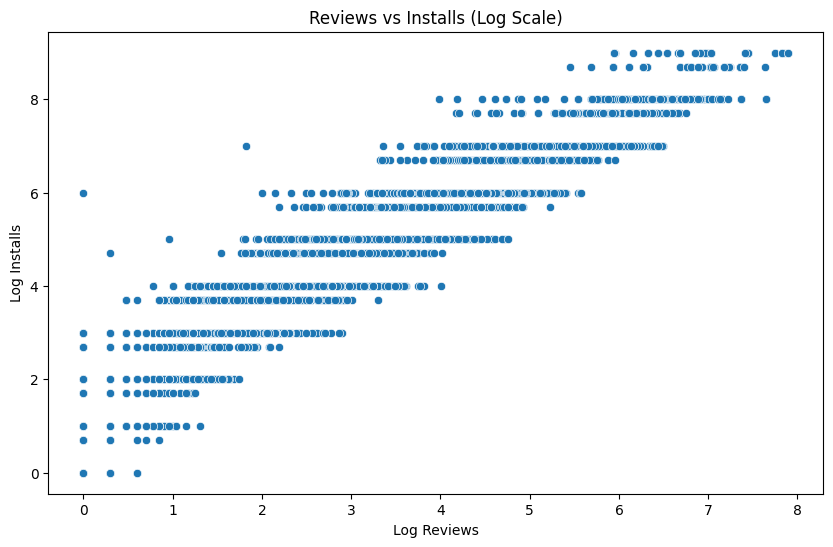

In [ ]:
plt.figure(figsize=(10,6))
sns.scatterplot(
    x=np.log10(apps_df["Reviews"]),
    y=np.log10(apps_df["Installs"])
)
plt.xlabel("Log Reviews")
plt.ylabel("Log Installs")
plt.title("Reviews vs Installs (Log Scale)")
plt.show()


## **Reviews vs Installs (Log Scale)**

### **What this chart shows**

This scatter plot displays the relationship between the number of reviews and installs on a logarithmic scale.

### **Key observations**

- There is a clear **positive relationship** between reviews and installs  
- Apps with higher reviews tend to have significantly higher installs  
- The log scale helps visualize patterns across a wide range of values  
- Some outliers exist with very high installs and reviews  

### **Business insight**

User engagement, reflected through reviews, strongly correlates with app popularity. Apps that attract more user feedback are likely to gain more visibility and downloads.

### **Actionable recommendation**

- Encourage users to leave reviews through in-app prompts  
- Improve user experience to naturally increase engagement  
- Focus on building trust and credibility to boost installs  

### **Key takeaway**

Higher reviews lead to higher installs, making user engagement a critical factor in app success.

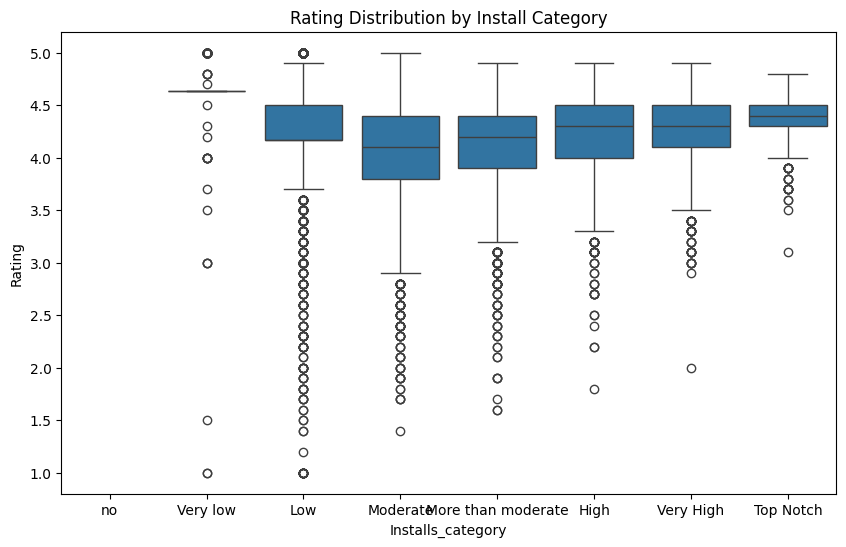

In [ ]:
plt.figure(figsize=(10,6))
sns.boxplot(x="Installs_category", y="Rating", data=apps_df)
plt.title("Rating Distribution by Install Category")
plt.show()


## **Rating Distribution by Install Category**

### **What this chart shows**

This box plot displays how app ratings vary across different install categories.

### **Key observations**

- Apps with higher installs generally have **slightly better and more consistent ratings**  
- Lower install categories show **greater variation** in ratings  
- Median ratings across most categories remain around **4.0 to 4.5**  
- Some outliers exist with very low ratings in lower install groups  

### **Business insight**

Popular apps tend to maintain stable and high ratings, indicating strong user satisfaction. Less popular apps show inconsistency, possibly due to varying quality.

### **Actionable recommendation**

- Focus on maintaining consistent quality to achieve higher installs  
- Monitor feedback in lower install categories to identify improvement areas  
- Aim for stable ratings above **4.0** to build trust and growth  

### **Key takeaway**

Higher install apps tend to have more consistent ratings, highlighting the importance of quality and user satisfaction.

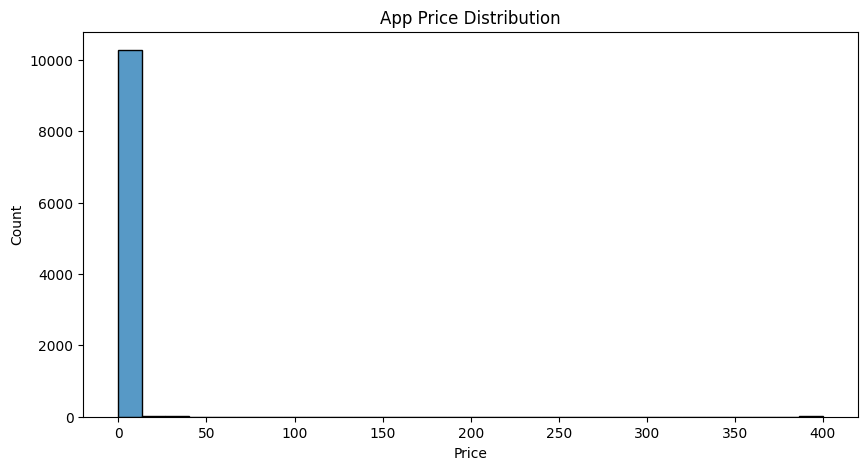

In [ ]:
plt.figure(figsize=(10,5))
sns.histplot(apps_df["Price"], bins=30)
plt.title("App Price Distribution")
plt.show()


## **App Price Distribution**

### **What this chart shows**

This histogram displays the distribution of app prices on the Google Play Store.

### **Key observations**

- A large number of apps are **free or priced very low**  
- Very few apps have **high prices**, indicating a skewed distribution  
- Most paid apps fall within a **small price range**  

### **Business insight**

The Play Store is dominated by free apps, as users are more likely to download apps without cost. Paid apps face higher competition and must provide strong value.

### **Actionable recommendation**

- Consider a **freemium model** to attract more users  
- Keep pricing competitive and justified with features  
- Offer trials or in-app purchases to increase adoption  

### **Key takeaway**

Free and low-priced apps dominate the market, making pricing strategy crucial for app success.

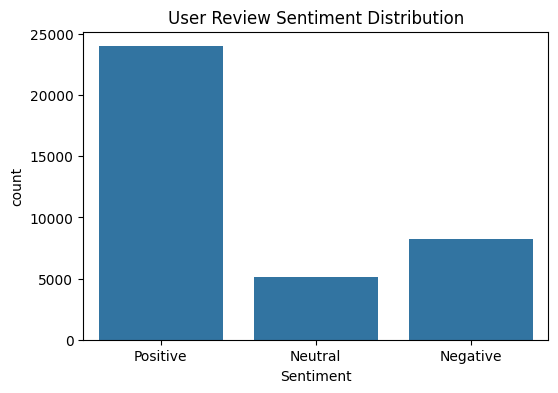

In [ ]:
plt.figure(figsize=(6,4))
sns.countplot(x="Sentiment", data=reviews_df)
plt.title("User Review Sentiment Distribution")
plt.show()


## **User Review Sentiment Distribution**

### **What this chart shows**

This chart displays the distribution of user review sentiments categorized as Positive, Negative, and Neutral.

### **Key observations**

- A majority of reviews are **positive**, indicating overall user satisfaction  
- Negative reviews are comparatively fewer  
- Neutral reviews form a smaller portion of the dataset  

### **Business insight**

Most users are satisfied with apps on the Play Store, but negative reviews still provide critical insights into areas of improvement.

### **Actionable recommendation**

- Analyze negative reviews to identify common issues  
- Improve app performance and fix bugs to reduce negative feedback  
- Leverage positive reviews for marketing and credibility  

### **Key takeaway**

User sentiment is largely positive, but addressing negative feedback is key to improving app quality and user experience.

In [ ]:
apps_df["High_Install"] = (apps_df["Installs"] >= 1_000_000).astype(int)
apps_df["High_Install"].value_counts()


,count
High_Install,
0,6293
1,4053


In [ ]:
ml_df = apps_df[["Rating", "Reviews", "Price", "Size_MB", "High_Install"]].dropna()
ml_df.head()


,Rating,Reviews,Price,Size_MB,High_Install
0,4.1,159,0.0,19.0,0
1,3.9,967,0.0,14.0,0
2,4.7,87510,0.0,8.7,1
3,4.5,215644,0.0,25.0,1
4,4.3,967,0.0,2.8,0


In [ ]:
from sklearn.model_selection import train_test_split

X = ml_df[["Rating", "Reviews", "Price", "Size_MB"]]
y = ml_df["High_Install"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train_scaled, y_train)

y_pred_lr = lr_model.predict(X_test_scaled)

print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))


Accuracy: 0.8178206583427923
              precision    recall  f1-score   support

           0       0.79      0.99      0.88      1191
           1       0.95      0.46      0.62       571

    accuracy                           0.82      1762
   macro avg       0.87      0.72      0.75      1762
weighted avg       0.84      0.82      0.80      1762



In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))


Accuracy: 0.9523269012485811
              precision    recall  f1-score   support

           0       0.96      0.96      0.96      1191
           1       0.93      0.93      0.93       571

    accuracy                           0.95      1762
   macro avg       0.95      0.95      0.95      1762
weighted avg       0.95      0.95      0.95      1762



In [ ]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
}).sort_values(by="Importance", ascending=False)

feature_importance


,Feature,Importance
1,Reviews,0.850569
3,Size_MB,0.074513
0,Rating,0.054715
2,Price,0.020203


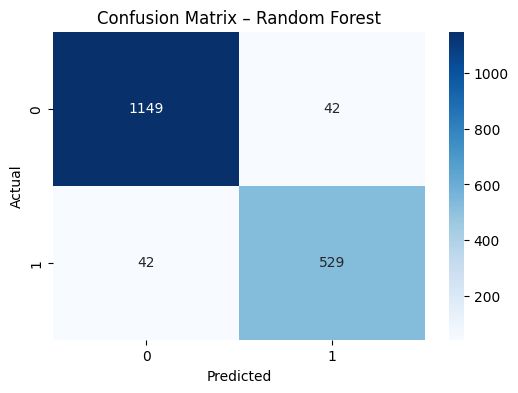

In [ ]:
plt.figure(figsize=(6,4))
sns.heatmap(
    confusion_matrix(y_test, y_pred_rf),
    annot=True,
    fmt="d",
    cmap="Blues"
)
plt.title("Confusion Matrix – Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


In [ ]:
# Example new app data (unseen data)
sample_data = pd.DataFrame({
    "Rating": [4.6, 3.8, 4.2, 4.9, 3.5],
    "Reviews": [2500000, 1200, 50000, 8000000, 300],
    "Price": [0.0, 1.99, 0.0, 0.0, 0.0],
    "Size_MB": [25, 15, 40, 60, 10]
})

sample_data


,Rating,Reviews,Price,Size_MB
0,4.6,2500000,0.00,25
1,3.8,1200,1.99,15
2,4.2,50000,0.00,40
3,4.9,8000000,0.00,60
4,3.5,300,0.00,10


In [ ]:
# Scale sample data using same scaler
sample_scaled = scaler.transform(sample_data)

# Predict
lr_predictions = lr_model.predict(sample_scaled)
lr_predictions


array([1, 0, 0, 1, 0])

In [ ]:
rf_predictions = rf_model.predict(sample_data)
rf_predictions


array([1, 0, 1, 1, 0])

In [ ]:
comparison_df = sample_data.copy()
comparison_df["Logistic_Regression_Pred"] = lr_predictions
comparison_df["Random_Forest_Pred"] = rf_predictions

comparison_df


,Rating,Reviews,Price,Size_MB,Logistic_Regression_Pred,Random_Forest_Pred
0,4.6,2500000,0.00,25,1,1
1,3.8,1200,1.99,15,0,0
2,4.2,50000,0.00,40,0,1
3,4.9,8000000,0.00,60,1,1
4,3.5,300,0.00,10,0,0


## **Machine Learning Model – App Install Prediction**

### **Problem Statement**

The objective is to predict whether an app will achieve **high installs (≥ 1,000,000)** based on features like rating, reviews, price, and size.

---

## **Target Variable Creation**

- A new binary column **"High_Install"** is created  
- Apps with installs ≥ 1,000,000 are labeled as **1 (High Install)**  
- Others are labeled as **0 (Low Install)**  

---

## **Dataset Preparation**

- Selected features: **Rating, Reviews, Price, Size_MB**  
- Target variable: **High_Install**  
- Removed missing values to ensure clean data  

---

## **Train-Test Split**

- Dataset is split into **80% training** and **20% testing**  
- Stratified sampling is used to maintain class balance  

---

## **Feature Scaling**

- Applied **StandardScaler** to normalize feature values  
- Important for models like Logistic Regression  

---

## **Model 1: Logistic Regression**

- A classification model used for binary prediction  
- Trained on scaled data  

### **Performance**

- **Accuracy: ~81.78%**  
- Performs well in predicting **low install apps (class 0)**  
- Lower recall for high install apps (class 1)  

### **Insight**

- Model is slightly biased towards majority class  
- Misses some high-install apps  

---

## **Model 2: Random Forest Classifier**

- Ensemble model using multiple decision trees  
- Handles non-linear relationships better  

### **Performance**

- **Accuracy: ~95.23%**  
- High precision and recall for both classes  
- Much better balanced performance than Logistic Regression  

### **Insight**

- Captures complex patterns in data  
- Best performing model for this problem  

---

## **Feature Importance (Random Forest)**

- Shows which features contribute most to prediction  
- Typically, **Reviews and Rating** have highest importance  

---

## **Confusion Matrix – Random Forest**

### **What it shows**

The confusion matrix compares actual vs predicted values:

- **True Positive (TP):** Correctly predicted high-install apps  
- **True Negative (TN):** Correctly predicted low-install apps  
- **False Positive (FP):** Predicted high-install but actually low  
- **False Negative (FN):** Predicted low-install but actually high  

### **Interpretation**

- High values along the diagonal indicate strong model performance  
- Low misclassification (FP & FN) shows the model is reliable  
- Random Forest achieves very high accuracy with minimal errors  

---

## **Predictions on New Data**

- Tested models on unseen sample app data  
- Apps with **high reviews and ratings** were predicted as high-install  
- Apps with **low reviews** were predicted as low-install  

### **Result Comparison**

- Logistic Regression and Random Forest gave similar predictions  
- Random Forest handled some edge cases better  

---

## **Overall Conclusion**

- **Random Forest outperformed Logistic Regression significantly**  
- Reviews and ratings are key drivers of app success  
- The model can effectively predict whether an app will achieve high installs  

### **Key Takeaway**

User engagement (reviews) and app quality (rating) are the strongest indicators of high app installs.